In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE #for handling imbalanced images dataset


import os
import pathlib


import cv2

In [2]:
trainDir=pathlib.Path("Tumor_dataset/Training/")
testDir=pathlib.Path("Tumor_dataset/Testing/")


In [3]:
list(trainDir.glob("*/*.jpg"))[:5]

[WindowsPath('Tumor_dataset/Training/glioma/Tr-glTr_0000.jpg'),
 WindowsPath('Tumor_dataset/Training/glioma/Tr-glTr_0001.jpg'),
 WindowsPath('Tumor_dataset/Training/glioma/Tr-glTr_0002.jpg'),
 WindowsPath('Tumor_dataset/Training/glioma/Tr-glTr_0003.jpg'),
 WindowsPath('Tumor_dataset/Training/glioma/Tr-glTr_0004.jpg')]

In [4]:
data_dict={
    'Glioma':list(trainDir.glob("glioma/*"))+list(testDir.glob("glioma/*")),
    'Meningioma':list(trainDir.glob("meningioma/*"))+list(testDir.glob("meningioma/*")),
    'No_tumor':list(trainDir.glob("notumor/*"))+list(testDir.glob("notumor/*")),
    'Pituitary':list(trainDir.glob("pituitary/*"))+list(testDir.glob("pituitary/*"))
}

In [5]:
data_label_dict={
    'Glioma':0,
    'Meningioma':1,
    'No_tumor':2,
    'Pituitary':3
}


In [6]:
img=cv2.imread(str(data_dict['Glioma'][0]))
img.shape

(512, 512, 3)

## Preparing data for model¶

In [7]:
X,y=[],[]

for CategoryName,CategoryImages in data_dict.items():
    for image in CategoryImages:
        img=cv2.imread(str(image))
        img=img/255
        resized_img=cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(data_label_dict[CategoryName])

In [9]:
X=np.array(X)
y=np.array(y)

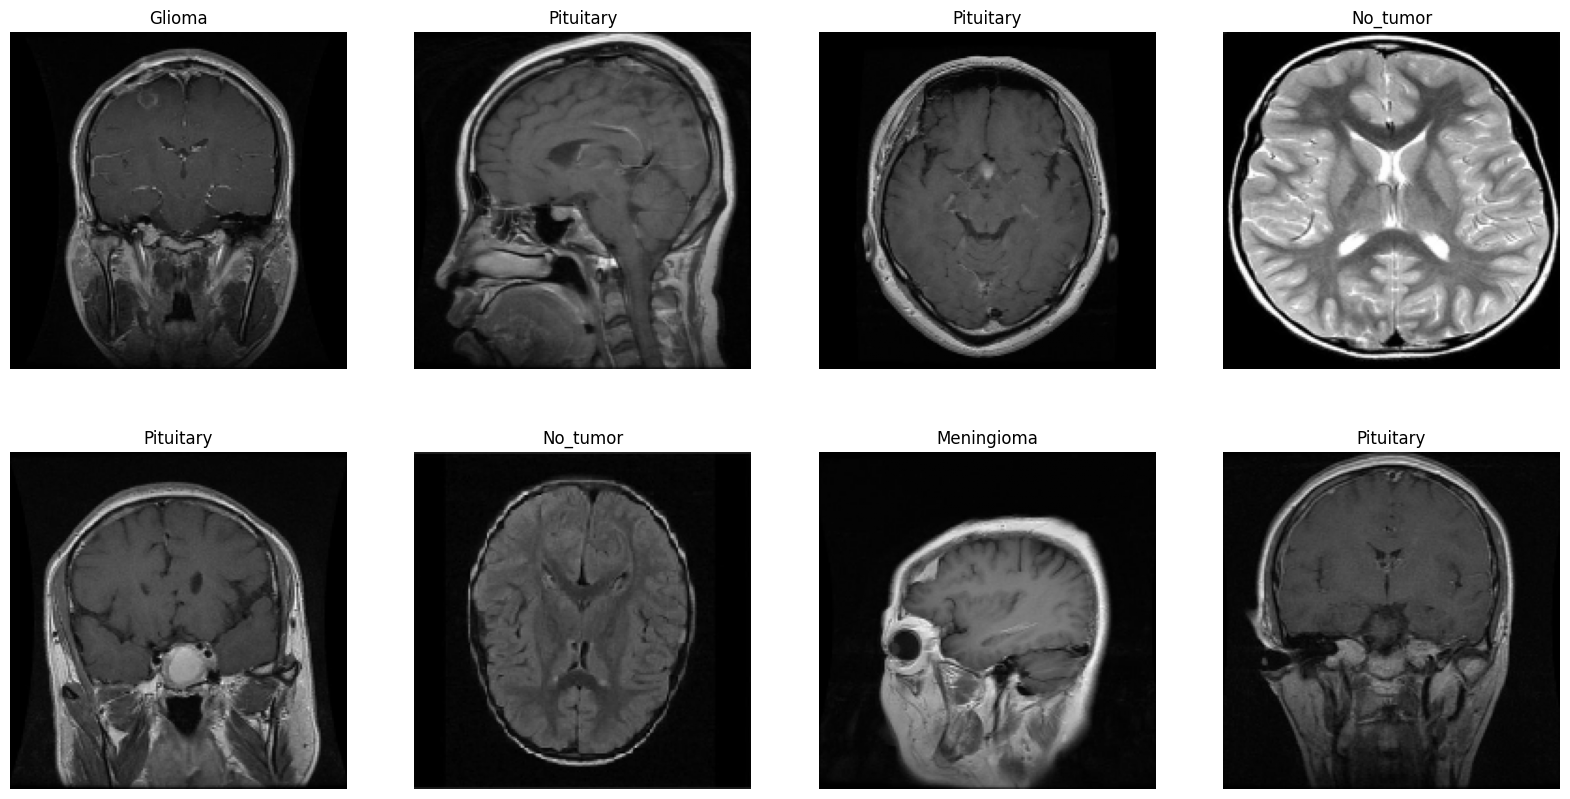

In [10]:
def getCategoryName(n):
    for x,y in data_label_dict.items():
        if y==n:
            return x


plt.figure(figsize=(20,10))
for n,i in enumerate(list(np.random.randint(0,len(X),8))):
    plt.subplot(2,4,n+1)
    plt.imshow(X[i])
    plt.axis('Off')
    plt.title(getCategoryName(y[i]))

## Splitting data in train and test

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
model=Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(180,180,3)),
    layers.MaxPool2D((2,2)),

    # layers.Conv2D(filters=32,kernal_size=(3,3),activation='relu',input_shape=(180,180,3)),
    # layers.MaxPool2D((2,2))

    #flattening and getting result
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(4,activation='sigmoid') #4 classes   
])

In [17]:

model.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 253472)            0         
                                                                 
 dense_2 (Dense)             (None, 64)                16222272  
                                                                 
 dense_3 (Dense)             (None, 4)                 260       
                                                                 
Total params: 16223428 (61.89 MB)
Trainable params: 16223428 (61.89 MB)
Non-trainable params: 0 (0.00 Byte)
____________

In [14]:
early_stopping=EarlyStopping(monitor='val_loss',#preventing overfitting
                             patience=3,
                             restore_best_weights=True)


In [15]:

history=model.fit(X_train,y_train,
                  epochs=15,
                  validation_data=(X_test,y_test),
                  callbacks=[early_stopping])

MemoryError: Unable to allocate 4.07 GiB for an array with shape (5618, 180, 180, 3) and data type float64